<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Exercise 15.15: Linear Regression with the Diabetes Dataset


In [ ]:
%matplotlib inline
from sklearn.datasets import load_diabetes

In [ ]:
diabetes = load_diabetes()

In [ ]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:
diabetes.data.shape

(442, 10)

In [ ]:
diabetes.target.shape

(442,)

In [ ]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [ ]:
# Exploring the Data with Pandas

In [ ]:
import pandas as pd

In [ ]:
pd.set_option('display.precision', 4)

In [ ]:
diabetes_df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

In [ ]:
diabetes_df['DiseaseProgression'] = pd.Series(diabetes.target)

In [ ]:
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


In [ ]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
count,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,442.0000
mean,-2.5118e-19,1.2308e-17,-2.2456e-16,-4.7976e-17,-1.3815e-17,3.9184e-17,-5.7772e-18,-9.0425e-18,9.2937e-17,1.1303e-17,152.1335
std,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,77.0930
min,-1.0723e-01,-4.4642e-02,-9.0275e-02,-1.1240e-01,-1.2678e-01,-1.1561e-01,-1.0231e-01,-7.6395e-02,-1.2610e-01,-1.3777e-01,25.0000
25%,-3.7299e-02,-4.4642e-02,-3.4229e-02,-3.6656e-02,-3.4248e-02,-3.0358e-02,-3.5117e-02,-3.9493e-02,-3.3246e-02,-3.3179e-02,87.0000
50%,5.3831e-03,-4.4642e-02,-7.2838e-03,-5.6704e-03,-4.3209e-03,-3.8191e-03,-6.5845e-03,-2.5923e-03,-1.9472e-03,-1.0777e-03,140.5000
75%,3.8076e-02,5.0680e-02,3.1248e-02,3.5644e-02,2.8358e-02,2.9844e-02,2.9312e-02,3.4309e-02,3.2432e-02,2.7917e-02,211.5000
max,1.1073e-01,5.0680e-02,1.7056e-01,1.3204e-01,1.5391e-01,1.9879e-01,1.8118e-01,1.8523e-01,1.3360e-01,1.3561e-01,346.0000


In [ ]:
#Visualizing the Features

In [ ]:
sample_df = diabetes_df.sample(frac=0.1, random_state=17)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
sns.set_style('whitegrid')

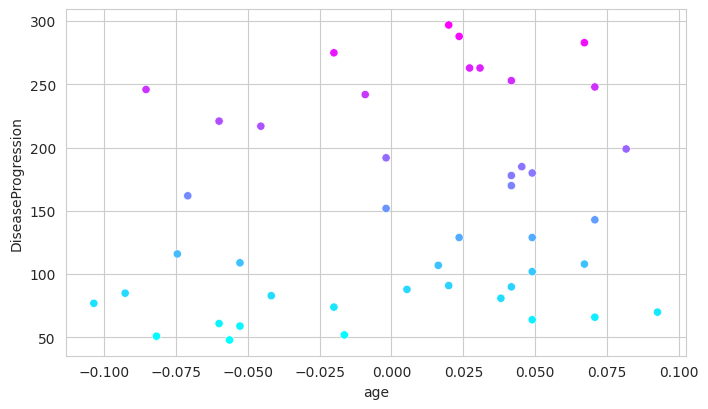

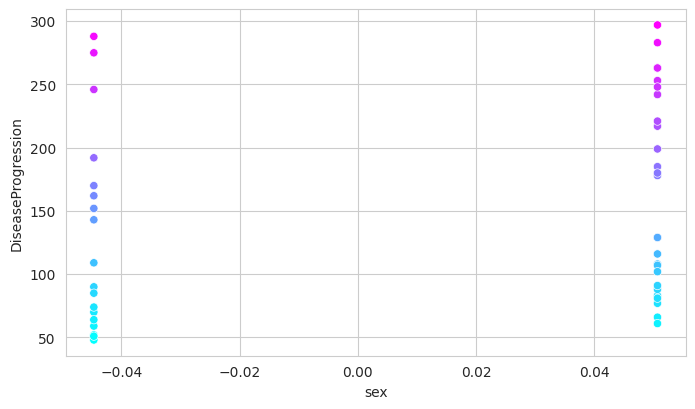

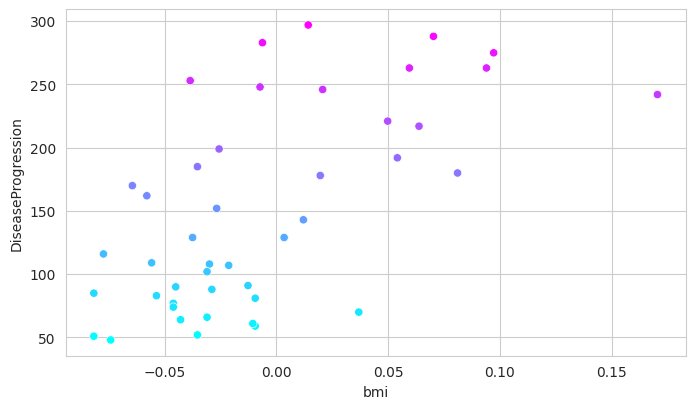

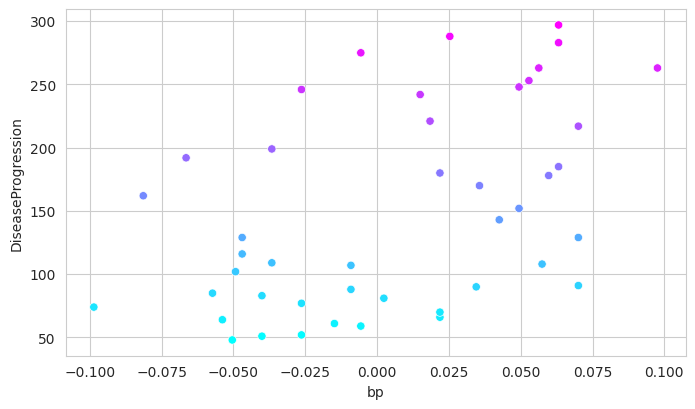

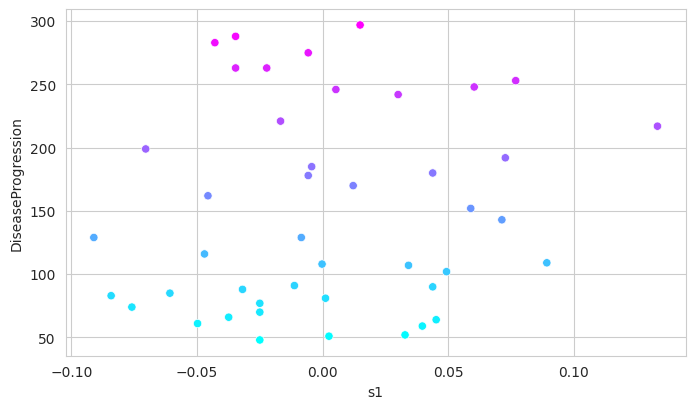

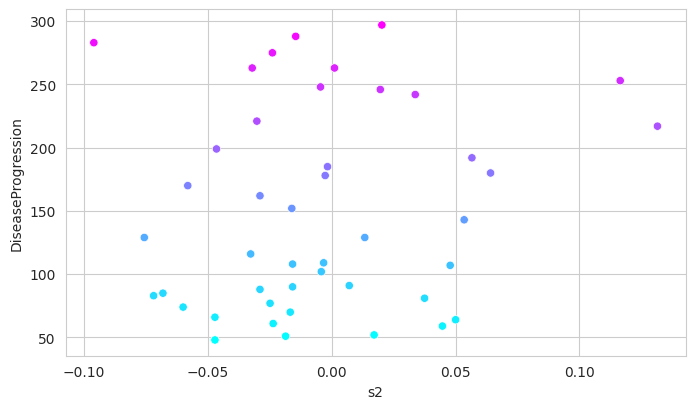

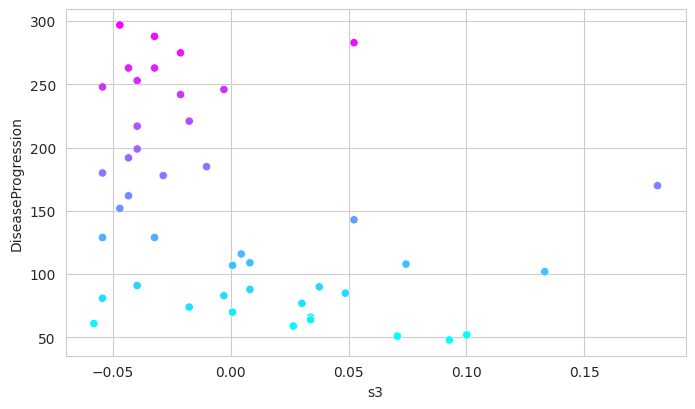

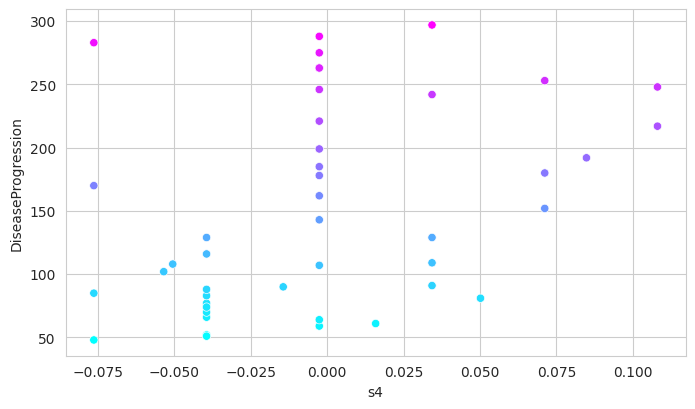

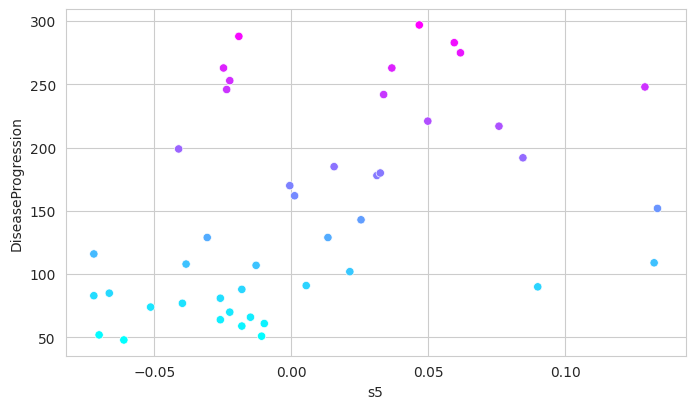

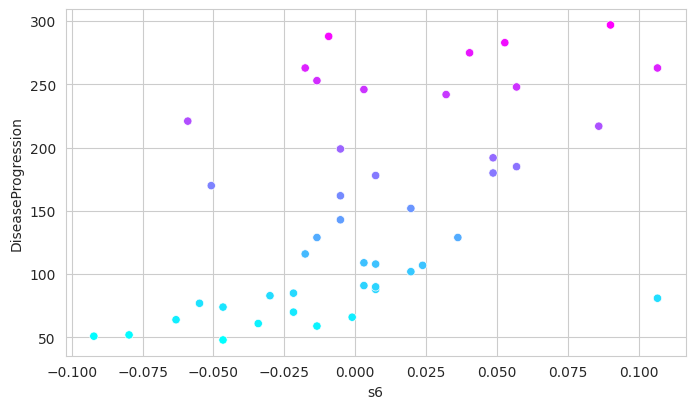

In [ ]:
for feature in diabetes.feature_names:
    plt.figure(figsize=(8, 4.5))

    sns.scatterplot(
        data=sample_df,
        x=feature,
        y='DiseaseProgression',
        hue='DiseaseProgression',
        palette='cool',
        legend=False
    )

In [ ]:
#Splitting the Data for Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data,
    diabetes.target,
    random_state=11
)

In [ ]:
X_train.shape

(331, 10)

In [ ]:
X_test.shape

(111, 10)

In [ ]:
#Training the Model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linear_regression = LinearRegression()

In [ ]:
linear_regression.fit(X=X_train, y=y_train)

LinearRegression()

In [ ]:
for i, name in enumerate(diabetes.feature_names):
    print(f'{name:>10}: {linear_regression.coef_[i]}')

       age: -60.21981405677291
       sex: -266.45705232203574
       bmi: 523.0634112596993
        bp: 310.5134699670048
        s1: -336.1614738106944
        s2: 137.3392923842451
        s3: -131.13923283453653
        s4: -1.1492348017315557
        s5: 622.3286855688128
        s6: 60.466457691682535


In [ ]:
linear_regression.intercept_

np.float64(152.22822762230342)

In [ ]:
predicted = linear_regression.predict(X_test)

In [ ]:
expected = y_test

In [ ]:
predicted[:5]

array([115.46474836,  83.4585369 , 160.77727376, 187.65710274,
        72.72122197])

In [ ]:
expected[:5]

array([ 79.,  55., 109., 178.,  39.])

In [ ]:
#Visualizing the Expected and Predicted Values

In [ ]:
df = pd.DataFrame()

In [ ]:
df['Expected'] = pd.Series(expected)

In [ ]:
df['Predicted'] = pd.Series(predicted)

In [ ]:
df.head()

,Expected,Predicted
0,79.0,115.4647
1,55.0,83.4585
2,109.0,160.7773
3,178.0,187.6571
4,39.0,72.7212


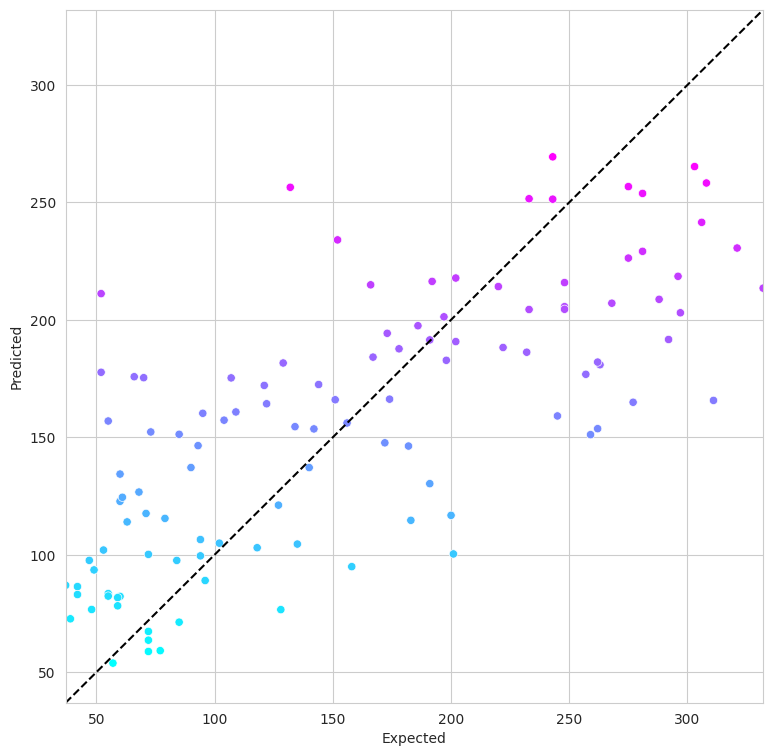

In [ ]:
figure = plt.figure(figsize=(9, 9))

axes = sns.scatterplot(
    data=df,
    x='Expected',
    y='Predicted',
    hue='Predicted',
    palette='cool',
    legend=False
)

start = min(expected.min(), predicted.min())

end = max(expected.max(), predicted.max())

axes.set_xlim(start, end)

axes.set_ylim(start, end)

line = plt.plot([start, end], [start, end], 'k--')

In [ ]:
#The dashed line represents perfect predictions, where the predicted value is equal to the expected value. Points closer to the dashed line indicate more accurate predictions.

In [ ]:
#Regression Model Metrics

In [ ]:
from sklearn import metrics

In [ ]:
metrics.r2_score(expected, predicted)

0.5322429620529407

In [ ]:
#The R² score measures how well the regression model explains the variation in the target values. A value closer to 1.0 represents a better fit.

In [ ]:
#Choosing the Best Model

In [ ]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

In [ ]:
estimators = {
    'LinearRegression': linear_regression,
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
for estimator_name, estimator_object in estimators.items():
    kfold = KFold(
        n_splits=10,
        random_state=11,
        shuffle=True
    )

    scores = cross_val_score(
        estimator=estimator_object,
        X=diabetes.data,
        y=diabetes.target,
        cv=kfold,
        scoring='r2'
    )

    print(
        f'{estimator_name:>16}: ' +
        f'mean of r2 scores={scores.mean():.3f}'
    )

LinearRegression: mean of r2 scores=0.475
      ElasticNet: mean of r2 scores=-0.002
           Lasso: mean of r2 scores=0.339
           Ridge: mean of r2 scores=0.421


In [ ]:
### Conclusion The models were compared using 10-fold cross-validation with the R² scoring metric. Linear Regression achieved the highest mean R² score of 0.475, followed by Ridge (0.421), Lasso (0.339), and ElasticNet (-0.002). Therefore, Linear Regression performed best among the four models tested on the Diabetes dataset.